<a href="https://colab.research.google.com/github/sumitjhadev/ai-attendance-project-app/blob/main/Smart_Food_Delivery_Risk_%26_ETA_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Regression target:
# delivery_time

# Classification target:
# late_delivery

In [ ]:
#First Step

import pandas as pd
df = pd.read_csv("delivery_data.csv")
df.head()

,distance_km,preparation_time,traffic_level,weather,courier_experience,order_value,hour,day_of_week,vehicle_type,delivery_time
0,5.12,16.5,Low,Rainy,10,315.76,17,Wednesday,Scooter,38.2
1,11.46,29.0,Low,Rainy,5,2287.16,11,Monday,Scooter,80.9
2,9.05,40.6,High,Clear,5,596.80,2,Saturday,Scooter,87.0
3,7.59,35.6,Low,Rainy,7,2079.94,8,Sunday,Scooter,75.0
4,2.72,38.2,Low,Clear,4,1429.88,1,Tuesday,Bike,50.4


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.describe()

,distance_km,preparation_time,courier_experience,order_value,hour,delivery_time
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000
mean,6.392930,27.74610,5.531000,1322.230300,11.58500,64.191500
std,3.213309,10.22657,2.823652,680.919124,6.86556,18.115914
min,1.050000,10.10000,1.000000,152.220000,0.00000,15.000000
25%,3.595000,18.40000,3.000000,741.182500,6.00000,51.275000
50%,6.465000,28.15000,6.000000,1290.765000,11.00000,64.400000
75%,9.185000,36.60000,8.000000,1909.437500,17.00000,76.900000
max,12.000000,45.00000,10.000000,2498.470000,23.00000,115.100000


In [ ]:
# Step 2 — EDA

df.isnull().sum()

,0
distance_km,0
preparation_time,0
traffic_level,0
weather,0
courier_experience,0
order_value,0
hour,0
day_of_week,0
vehicle_type,0
delivery_time,0


In [ ]:
df['delivery_time'].describe()
df.corr(numeric_only=True)

,distance_km,preparation_time,courier_experience,order_value,hour,delivery_time
distance_km,1.000000,0.029337,-0.053335,-0.020215,-0.051317,0.617230
preparation_time,0.029337,1.000000,-0.014663,-0.038308,-0.035126,0.585524
courier_experience,-0.053335,-0.014663,1.000000,0.001329,-0.044439,-0.149840
order_value,-0.020215,-0.038308,0.001329,1.000000,-0.048436,-0.054906
hour,-0.051317,-0.035126,-0.044439,-0.048436,1.000000,0.091000
delivery_time,0.617230,0.585524,-0.149840,-0.054906,0.091000,1.000000


In [ ]:
# Step 4 — Feature engineering

df["is_peak_hour"] = df["hour"].between(18,21).astype(int)
print(df["is_peak_hour"].value_counts())

is_peak_hour
0    841
1    159
Name: count, dtype: int64


<Axes: xlabel='hour'>

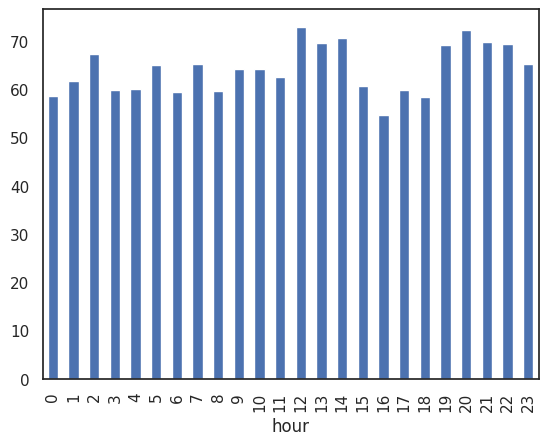

In [ ]:
df.groupby('hour')['delivery_time'].mean().plot(kind='bar')

In [ ]:
df["distance_per_experience"] = (
    df["distance_km"] / (df["courier_experience"] + 1)
)

df["distance_per_experience"].value_counts()

,count
distance_per_experience,
0.300000,5
0.480000,4
1.320000,4
1.760000,3
1.481250,3
...,...
3.110000,1
1.068333,1
2.070000,1


In [ ]:
# Step 5 — Create the classification target( Suppose late means:more than35 mins.)

df["late_delievery"] = df["delivery_time"] > 35
df["late_delievery"] = df["late_delievery"].astype(int)
df["late_delievery"].value_counts()



,count
late_delievery,
1,945
0,55


In [ ]:
# Step 6 — Understand X and y properly

# X = information available BEFORE prediction
# y = thing we want to predict

X = df.drop(columns = ["delivery_time","late_delievery"])
y = df["delivery_time"]

In [ ]:
# Step 7 — Train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

ValueError: could not convert string to float: 'Medium'

In [ ]:
df.head()

,distance_km,preparation_time,traffic_level,weather,courier_experience,order_value,hour,day_of_week,vehicle_type,delivery_time,is_peak_hour,distance_per_experience,late_delievery
0,5.12,16.5,Low,Rainy,10,315.76,17,Wednesday,Scooter,38.2,0,0.465455,1
1,11.46,29.0,Low,Rainy,5,2287.16,11,Monday,Scooter,80.9,0,1.910000,1
2,9.05,40.6,High,Clear,5,596.80,2,Saturday,Scooter,87.0,0,1.508333,1
3,7.59,35.6,Low,Rainy,7,2079.94,8,Sunday,Scooter,75.0,0,0.948750,1
4,2.72,38.2,Low,Clear,4,1429.88,1,Tuesday,Bike,50.4,0,0.544000,1
